## ***Import Librarries***

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [4]:
titanic_df = pd.read_csv("./titanic.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
for column in titanic_df.columns:
    print(f'- {column}')

- PassengerId
- Survived
- Pclass
- Name
- Sex
- Age
- SibSp
- Parch
- Ticket
- Fare
- Cabin
- Embarked


In [6]:
titanic_df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [7]:
numeric_columns = titanic_df.select_dtypes(include= 'int64')
print('Numeric columns in the DataFrame:\n')
for column in numeric_columns:
    print('- ', column)

Numeric columns in the DataFrame:

-  PassengerId
-  Survived
-  Pclass
-  SibSp
-  Parch


In [8]:
float_columns = titanic_df.select_dtypes(include= 'float')
print('Float columns in the DataFrame:\n')
for column in float_columns:
    print('- ', column)

Float columns in the DataFrame:

-  Age
-  Fare


In [9]:
categorical_columns = titanic_df.select_dtypes(include= 'object')
print('Categorical columns in the DataFrame:\n')
for column in categorical_columns:
    print('- ', column)

Categorical columns in the DataFrame:

-  Name
-  Sex
-  Ticket
-  Cabin
-  Embarked


In [10]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
titanic_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
titanic_df.isnull().sum() / len(titanic_df) * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

<Axes: >

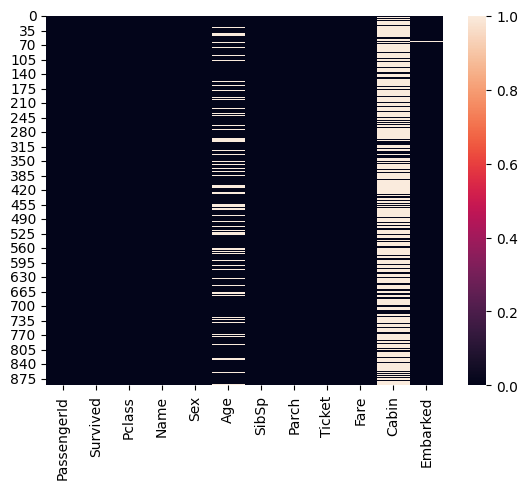

In [14]:
sns.heatmap(titanic_df.isnull())

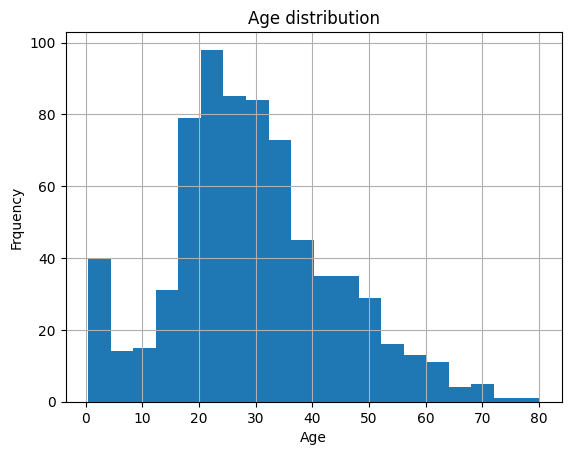

In [15]:
titanic_df['Age'].hist(bins= 20)
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Frquency')
plt.show()

In [13]:
numeric_df = pd.DataFrame(titanic_df.select_dtypes('number'))
numeric_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


<Axes: >

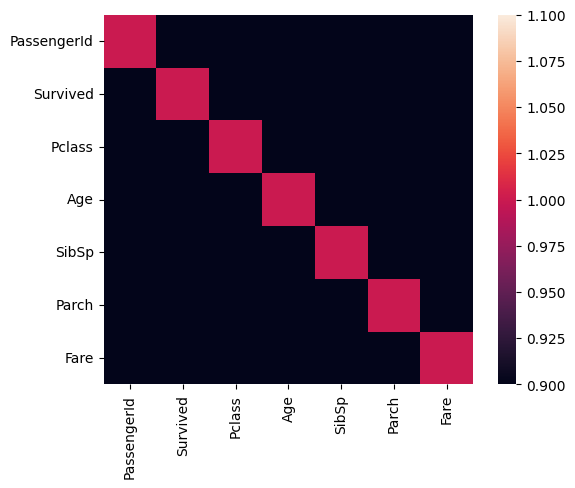

In [14]:
corr = numeric_df.corr()

sns.heatmap(corr,vmin= 1.0,  vmax= 1.0, square= True)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


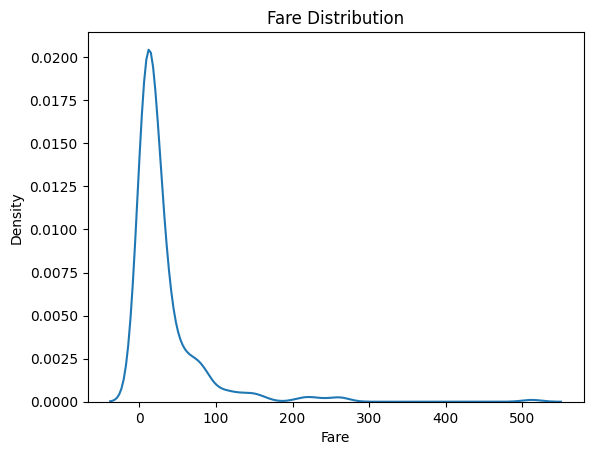

In [15]:
sns.kdeplot(titanic_df['Fare'].dropna())
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Density')
plt.show()


In [16]:
titanic_df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

## ***Drop irrelevant columns***

## ***Handle missing values***
- Impute 'age' with the mean

In [17]:
imputer_age = SimpleImputer(strategy="mean")
titanic_df["Age"] = imputer_age.fit_transform(titanic_df[["Age"]])

- Impute 'embarked' with the most frequent value

In [18]:
imputer_embarked = SimpleImputer(strategy="most_frequent")
titanic_df["Embarked"] = imputer_embarked.fit_transform(titanic_df[["Embarked"]]).ravel()

## ***Encode categorical features***
- 'sex' column

In [19]:
le = LabelEncoder()
titanic_df["Sex"] = le.fit_transform(titanic_df["Sex"])

- 'embarked' column

In [20]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
embarked_encoded = ohe.fit_transform(titanic_df[["Embarked"]])
embarked_df = pd.DataFrame(embarked_encoded, columns=ohe.get_feature_names_out(["Embarked"]))
titanic_df = pd.concat([titanic_df, embarked_df], axis=1)
titanic_df.drop("Embarked", axis=1, inplace=True)

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


## **Feature Scaling for 'fare' and 'age'**

In [21]:
scaler = StandardScaler()
titanic_df[["Fare", "Age"]] = scaler.fit_transform(titanic_df[["Fare", "Age"]])

## ***Define features (X) and target (y)***

In [22]:
X = titanic_df.drop("Survived", axis=1)
y = titanic_df["Survived"]

## ***Split the data into training and testing sets***

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## ***Save preprocessed data for model training***

In [24]:
X_train.to_csv(r"X_train.csv", index=False)
X_test.to_csv(r"X_test.csv", index=False)
y_train.to_csv(r"y_train.csv", index=False)
y_test.to_csv(r"y_test.csv", index=False)